## Part 1: Machine Learn the Dataset

In [ ]:
import kagglehub
import pandas as pd

path = kagglehub.dataset_download("uciml/indian-liver-patient-records")

# First let's explore the data
df = pd.read_csv(path + "/indian_liver_patient.csv")

# Take a look at some rows and overall numbers across dataset
print("First 5 rows:")
display(df.head())
print("Last 5 rows:")
display(df.tail())
print("Shape:", df.shape,"\n")
print("Info:")
df.info()
print("\nSummary Statistics:")
display(df.describe())

# Missing values or duplicates
print("Null values: \n", df.isnull().sum()) # 4 nulls in Albumin_and_Globulin_Ratio column
print("\nDuplicate rows:", df.duplicated().sum()) # 13 duplicates

In [ ]:
import matplotlib.pyplot as plt

# Create some plots to see how some columns correlate with disease
# Data shows that fewer disease patients are young
age_plot = df.iloc[df['Dataset']==1].groupby('Age')[['Dataset']].count().reset_index() # Queried ChatGPT to find out I needed to reset_index
age_plot.plot(x='Age',y='Dataset', kind='scatter', title='Number of Liver Disease Patients by Age', ylabel='Number of Patients')

# # Data shows that most disease patients are males, could be biased dataset though
gender_plot = df.iloc[df['Dataset']==1].groupby('Gender')[['Dataset']].count().reset_index()
gender_plot.plot(x='Gender', y='Dataset', kind='bar', title='Number of Liver Disease Patients by Gender', ylabel='Number of Patients', legend=False)

# Data shows that patients with higher bilirubin levels are more likely to have liver disease, this makes sense as the liver processes bilirubin
plt.figure()
bilirubin_plot1 = df.iloc[df['Dataset']==1].groupby('Total_Bilirubin')[['Dataset']].count().reset_index()
bilirubin_plot2 = df.iloc[df['Dataset']==2].groupby('Total_Bilirubin')[['Dataset']].count().reset_index()
plt.scatter(bilirubin_plot1['Total_Bilirubin'], bilirubin_plot1['Dataset'], label='Liver Disease')
plt.scatter(bilirubin_plot2['Total_Bilirubin'], bilirubin_plot2['Dataset'], label='No Liver Disease')
plt.xlabel('Total Bilirubin')
plt.ylabel('Number of Patients')
plt.title('Number of Liver Patients by Bilirubin')
plt.legend()
plt.show()

# Data shows that patients with higher Alkaline_Phosphotase levels are more likely to have liver disease
plt.figure()
df_disease = df.iloc[df['Dataset']==1]
df_no_disease = df.iloc[df['Dataset']==2]
plt.scatter(df_disease['Alkaline_Phosphotase'], df_disease['Dataset'], label='Liver Disease')
plt.scatter(df_no_disease['Alkaline_Phosphotase'], df_no_disease['Dataset'], label='No Liver Disease')
plt.xlabel('Alkaline_Phosphotase')
plt.ylabel('Dataset Value')
plt.title('Number of Liver Patients by Alkaline_Phosphotase')
plt.legend()
plt.show()

# Data shows that total protein does not indicate much
plt.figure()
plt.scatter(df_disease['Total_Protiens'], df_disease['Dataset'], label='Liver Disease')
plt.scatter(df_no_disease['Total_Protiens'], df_no_disease['Dataset'], label='No Liver Disease')
plt.xlabel('Total_Protein')
plt.ylabel('Dataset Value')
plt.title('Number of Liver Patients by Total_Protein')
plt.legend()
plt.show()

# Data shows that Albumin does not indicate much
plt.figure(figsize=(10,5))
plt.scatter(df_disease['Albumin'], df_disease['Dataset'], label='Liver Disease')
plt.scatter(df_no_disease['Albumin'], df_no_disease['Dataset'], label='No Liver Disease')
plt.xlabel('Albumin')
plt.ylabel('Dataset Value')
plt.title('Number of Liver Patients by Albumin')
plt.legend()
plt.show()

In [ ]:
import numpy as np

# Detect anomalies with IQR, Total bilirubin
Q1 = df['Total_Bilirubin'].quantile(0.25)
Q3 = df['Total_Bilirubin'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
bilirubin_outliers = df[(df['Total_Bilirubin'] < lower) | (df['Total_Bilirubin'] > upper)]
print("Bilirubin Outliers:\n")
display(bilirubin_outliers)
fig, ax = plt.subplots(figsize=(20,5))
ax.boxplot(df['Total_Bilirubin'], orientation='horizontal')
ax.set_title('Total_Bilirubin')
plt.show()

# Alkaline Phosphotase
Q1 = df['Alkaline_Phosphotase'].quantile(0.25)
Q3 = df['Alkaline_Phosphotase'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
alkaline_phosphotase_outliers = df[(df['Alkaline_Phosphotase'] < lower) | (df['Alkaline_Phosphotase'] > upper)]
print("Alkaline_Phosphotase Outliers:\n")
display(alkaline_phosphotase_outliers)
fig, ax = plt.subplots(figsize=(20,5))
ax.boxplot(df['Alkaline_Phosphotase'], orientation='horizontal')
ax.set_title('Alkaline_Phosphotase')
plt.show()

# Alamine_Aminotransferase
Q1 = df['Alamine_Aminotransferase'].quantile(0.25)
Q3 = df['Alamine_Aminotransferase'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
alamine_aminotransferase_outliers = df[(df['Alamine_Aminotransferase'] < lower) | (df['Alamine_Aminotransferase'] > upper)]
print("Alamine_Aminotransferase Outliers:\n")
display(alamine_aminotransferase_outliers)
fig, ax = plt.subplots(figsize=(20,5))
ax.boxplot(df['Alamine_Aminotransferase'], orientation='horizontal')
ax.set_title('Alamine_Aminotransferase')
plt.show()

# Total_Protiens
Q1 = df['Total_Protiens'].quantile(0.25)
Q3 = df['Total_Protiens'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
total_protiens_outliers = df[(df['Total_Protiens'] < lower) | (df['Total_Protiens'] > upper)]
print("Total_Protiens Outliers:\n")
display(total_protiens_outliers)
fig, ax = plt.subplots(figsize=(20,5))
ax.boxplot(df['Total_Protiens'], orientation='horizontal')
ax.set_title('Total_Protiens')
plt.show()

In [ ]:
# Create a heatmap to check correlation between features, I used YouTube and Google's AI overview for syntax/formatting help
numerical_df = df.drop(['Gender', 'Dataset'], axis=1)
corr_df = numerical_df.corr()

fig = plt.figure(figsize=(9,9))
plt.imshow(corr_df, cmap='Blues')
plt.colorbar()
plt.xticks(range(9),corr_df.index, rotation=45, ha='right',rotation_mode='anchor')
plt.yticks(range(9),corr_df.index, ha='right',rotation_mode='anchor')
plt.title("Patient Feature Heatmap")
plt.show()

In [ ]:
# Clean up the dataset

# Reduce multicollinearity as per the heat map
clean_df = df.drop(['Direct_Bilirubin','Aspartate_Aminotransferase','Albumin'],axis=1)
# Drop duplicate rows
clean_df = clean_df.drop_duplicates()
# Drop null values
clean_df = clean_df.dropna()
# Winsorize extreme values
from scipy.stats.mstats import winsorize
clean_df['Total_Bilirubin'] = winsorize(clean_df['Total_Bilirubin'],limits=[0.25, 0.25]) # Used ChatGPT to find out I can reassign easily
clean_df['Alkaline_Phosphotase'] = winsorize(clean_df['Alkaline_Phosphotase'],limits=[0.25, 0.25])
clean_df['Alamine_Aminotransferase'] = winsorize(clean_df['Alamine_Aminotransferase'],limits=[0.25, 0.25])
clean_df['Total_Protiens'] = winsorize(clean_df['Total_Protiens'],limits=[0.25, 0.25])

In [ ]:
# Some features are heavily right skewed, which can negatively impact a logistic regression. Applying a log transformation
# stabalizes stabilizes the variance and reduces skewness

clean_df[['Total_Bilirubin','Alkaline_Phosphotase','Alamine_Aminotransferase']] = np.log1p(clean_df[['Total_Bilirubin','Alkaline_Phosphotase','Alamine_Aminotransferase']])

In [ ]:
# Remap the target column range from [1,2] to [1,0]
clean_df['Dataset'] = 1 // clean_df['Dataset'] # 1 maps to 1 and 2 maps to 0

In [ ]:
# Encode Gender column
from sklearn.preprocessing import OneHotEncoder, StandardScaler
encoder = OneHotEncoder(sparse_output=False)
encoded_gender_df = pd.DataFrame(encoder.fit_transform(clean_df[['Gender']]), columns=encoder.get_feature_names_out(['Gender']))

    # Used ChatGPT to find out that reset index matters
clean_df = pd.concat([clean_df.reset_index(drop=True), encoded_gender_df.reset_index(drop=True)], axis=1)
clean_df = clean_df.drop(['Gender'], axis=1)
# Scale all other numerical features
scaler = StandardScaler()
clean_df[['Age', 'Total_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Total_Protiens']] = scaler.fit_transform(clean_df[['Age', 'Total_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Total_Protiens']])

In [ ]:
# Split the dataset to prepare for training
from sklearn.model_selection import train_test_split

df_data = pd.concat([clean_df.iloc[:,0:6],clean_df.iloc[:,7:]],axis=1)
df_target = clean_df.iloc[:,[6]]

# Note stratification due to class imbalance, i.e. there are many more rows of one class than another
X_train, X_test, y_train, y_test = train_test_split(df_data, df_target, test_size=0.2, random_state=42, stratify=df_target)

In [ ]:
# Visualize the class imbalance
disease_plot = df.groupby('Dataset')[['Dataset']].count()
disease_plot.plot(kind='bar', title='Number of Liver Disease Patients', ylabel='Number of Patients', xlabel='1 = Disease, 2 = No Disease')
display(disease_plot)
plt.show()

In [ ]:
# Balance the classes using SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE()
X_smote, y_smote = smote.fit_resample(X_train, y_train)

In [ ]:
# Actually train a model with what we've been working towards with a logistic regression
from sklearn.linear_model import LogisticRegression

regressor = LogisticRegression(class_weight='balanced', max_iter=1000)
regressor.fit(X_smote, y_smote)

In [ ]:
# Now make our predicitions with the trained model
y_pred = regressor.predict(X_test)

In [ ]:
# Get some metrics about how the model performed
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

print("~~~~~~Prediction Metrics:~~~~~~")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues) 
plt.title("Confusion Matrix")
plt.show() 

## Part 2: Creating Some Machine Learning Concepts From Scratch

In [ ]:
def sigmoid(x):
    return np.clip(1/(1+np.e**(-x)), -500, 500)

In [ ]:
def cost(y_pred, y_test):
    y_pred = pd.DataFrame(y_pred, columns=['Dataset']).reset_index(drop=True)
    y_test = y_test.reset_index(drop=True)
    cost = 0
    m = len(y_pred)
    if m != len(y_test): return "Both vectors must be the same dimensions"
    for i in range(m):
        cost += (y_pred.iloc[i] - y_test.iloc[i])**2
    return np.clip(cost / (2*m), 1e-15, 1 - 1e-15)

In [53]:
# Cost-Iteration Metrics for plot
cost_function_data = []

# I used ChatGPT to understand the structure (originally I had 3 for loops), but I condensed it down with proper linear algebra
def gradient_descent(X_train, y_train, rate, max_iter=1000):
    coef = [0]*(X_train.shape[1])
    # m is number of samples, n is number of features a sample has
    m = X_train.shape[0]
    n = X_train.shape[1]
    model_error = cost(sigmoid(X_train @ coef), y_train).iloc[0]
    cost_function_data.append(model_error)

    for i in range(max_iter):
        errors = sigmoid(X_train @ coef) - y_train.iloc[:,0]

        # Dot product the errors with each feature column
        gradients = (rate/m) * (X_train.transpose() @ errors)
        coef = coef - gradients

        # Calculate cost with adjusted coefficients and see if it changed at all, if it converged then break
        new_error = cost(sigmoid(X_train @ coef), y_train).iloc[0]
        cost_function_data.append(new_error)

        if (np.isclose(model_error, new_error)): 
            break
        # Otherwise update model_error
        model_error = new_error
    return coef

In [ ]:
# Add an intercept term to the dataset, SMOTE already applied
X_smote['Intercept'] = [1] * X_smote.shape[0]
X_test['Intercept'] = [1] * X_test.shape[0]
X_smote # the training set

In [59]:
# Train the model with the gradient descent function
coef = gradient_descent(X_smote, y_smote, rate=0.01, max_iter=1000)
display(coef)

Age                           0.290296
Total_Bilirubin               0.403661
Alkaline_Phosphotase          0.448301
Alamine_Aminotransferase      0.365433
Total_Protiens                0.170625
Albumin_and_Globulin_Ratio    0.058098
Gender_Female                 0.107605
Gender_Male                   0.022306
Intercept                     0.129911
dtype: float64

In [62]:
# Predict with the trained model
y_pred_scratch = np.floor(sigmoid(X_test @ coef).reset_index(drop=True) * 2)
display(y_pred_scratch)

0      1.0
1      1.0
2      1.0
3      0.0
4      1.0
      ... 
109    0.0
110    1.0
111    1.0
112    1.0
113    1.0
Length: 114, dtype: float64

In [63]:
# Evaluation metrics (looks good!)
print("~~~~~~Prediction Metrics:~~~~~~")
print("Accuracy:", accuracy_score(y_test, y_pred_scratch))
print("Precision:", precision_score(y_test, y_pred_scratch))
print("Recall:", recall_score(y_test, y_pred_scratch))
print("F1-Score:", f1_score(y_test, y_pred_scratch))

~~~~~~Prediction Metrics:~~~~~~
Accuracy: 0.7280701754385965
Precision: 0.890625
Recall: 0.7037037037037037
F1-Score: 0.7862068965517242


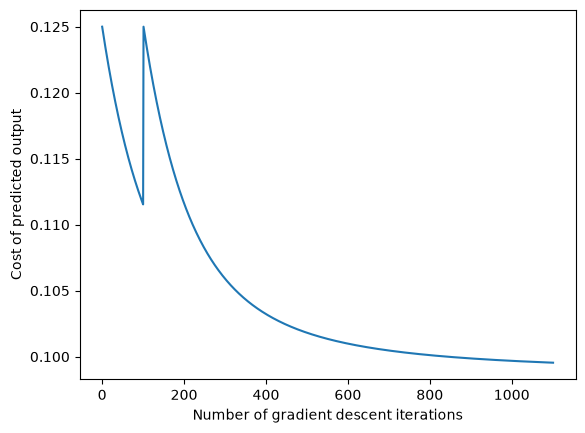

In [64]:
cost_function_df = pd.DataFrame(cost_function_data)
plt.figure()
plt.plot(cost_function_df,)
plt.xlabel("Number of gradient descent iterations")
plt.ylabel("Cost of predicted output")
plt.show()